# Organized ERCP Benchmark Notebook


In [10]:
import os
import json
import copy
import time
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    auc,
    average_precision_score,
    precision_recall_curve,
)
from tqdm import tqdm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    device = torch.device('cuda')
else:
    print('WARNING: Using CPU')
    device = torch.device('cpu')

CUDA available: True
GPU: NVIDIA RTX 6000 Ada Generation
VRAM: 50.9 GB


In [11]:
DATA_ROOT = '/mounts/mecd-ap-g5/data'
PROCESSED_IMAGES_DIR = os.path.join(DATA_ROOT, 'MIQR-CC-Dataset', 'processed')
METADATA_PATH = os.path.join(DATA_ROOT, 'MIQR-CC-Dataset', 'metadata.csv')
NOTEBOOK_NAME = 'organized_benchmark'
RESULTS_ROOT = '/mounts/mecd-ap-g5/results'
MODELS_ROOT = '/mounts/mecd-ap-g5/models'
RESULTS_DIR = os.path.join(RESULTS_ROOT, NOTEBOOK_NAME)
MODELS_DIR = os.path.join(MODELS_ROOT, NOTEBOOK_NAME)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print(f'DATA_ROOT: {DATA_ROOT}')
print(f'PROCESSED_IMAGES_DIR: {PROCESSED_IMAGES_DIR}')
print(f'METADATA_PATH: {METADATA_PATH}')

df = pd.read_csv(METADATA_PATH)
print('\nTotal samples:', len(df))
print('\nHead:')
print(df.head())
print('\nDtypes:')
print(df.dtypes)
print('\nMissing values:')
print(df.isna().sum())

path_check_sample = df['processed_image_path'].head(10).apply(lambda path: os.path.exists(os.path.join(DATA_ROOT, 'MIQR-CC-Dataset', path)))
print('\nSample processed image path checks:')
print(path_check_sample)

DATA_ROOT: /mounts/mecd-ap-g5/data
PROCESSED_IMAGES_DIR: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset/processed
METADATA_PATH: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset/metadata.csv

Total samples: 19317

Head:
     raw_image_path    processed_image_path  patient_id image_type sex  \
0  raw/1_image1.png  processed/1_image1.png           1          S   M   
1  raw/1_image2.png  processed/1_image2.png           1          S   M   
2  raw/1_image3.png  processed/1_image3.png           1          S   M   
3  raw/1_image4.png  processed/1_image4.png           1          S   M   
4  raw/2_image5.png  processed/2_image5.png           2          S   F   

   birth_date   exam_date exam_time   age   equipment_model       Label  \
0  22/08/1952  03/02/2022  11:50:32  69.0  Ziehm Vision RFD  Unlabelled   
1  22/08/1952  03/02/2022  11:47:43  69.0  Ziehm Vision RFD  Unlabelled   
2  22/08/1952  03/02/2022  12:08:45  69.0  Ziehm Vision RFD  Unlabelled   
3  22/08/1952  03/02/2022  11:50:22  69.0  Ziehm Vi

In [12]:
EXCLUDED_LABELS = {'unlabeled', 'unlabelled', 'unlabbeled'}

keep_mask = df['Keep'].astype(str).str.strip().str.lower().eq('keep')
label_mask = ~df['Label'].astype(str).str.strip().str.lower().isin(EXCLUDED_LABELS)

df_filtered = df[keep_mask & label_mask].copy()

print('Label counts after filtering:')
label_counts = df_filtered['Label'].value_counts()
print(label_counts)
print('\nLabel percentages:')
print((label_counts / len(df_filtered) * 100).round(2))
print('\nCross-tab of image_type vs Label:')
print(pd.crosstab(df_filtered['image_type'], df_filtered['Label']))

filtered_csv_path = os.path.join(RESULTS_DIR, 'filtered_metadata.csv')
filtered_parquet_path = os.path.join(RESULTS_DIR, 'filtered_metadata.parquet')
os.makedirs(RESULTS_DIR, exist_ok=True)
df_filtered.to_csv(filtered_csv_path, index=False)
try:
    df_filtered.to_parquet(filtered_parquet_path, index=False)
    print(f'Saved filtered parquet to {filtered_parquet_path}')
except Exception as exc:
    print(f'Parquet save skipped: {exc}')
print(f'Saved filtered CSV to {filtered_csv_path}')

Label counts after filtering:
Label
Lithiasis              726
Malignant Stricture    329
Normal                 299
Biliary Leaks          151
Benign Stricture        63
Name: count, dtype: int64

Label percentages:
Label
Lithiasis              46.30
Malignant Stricture    20.98
Normal                 19.07
Biliary Leaks           9.63
Benign Stricture        4.02
Name: count, dtype: float64

Cross-tab of image_type vs Label:
Label       Benign Stricture  Biliary Leaks  Lithiasis  Malignant Stricture  \
image_type                                                                    
S                         63            146        712                  324   
V                          0              5         14                    5   

Label       Normal  
image_type          
S              276  
V               23  
Parquet save skipped: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet suppor

In [13]:
SEED = 42
benchmark_df = df_filtered.copy()
benchmark_df['image_path'] = benchmark_df['processed_image_path'].apply(lambda path: os.path.join(DATA_ROOT, 'MIQR-CC-Dataset', path))
benchmark_df = benchmark_df[benchmark_df['image_path'].apply(os.path.exists)].copy()
benchmark_df['target'] = benchmark_df['Label'].astype('category').cat.codes
class_names = list(benchmark_df['Label'].astype('category').cat.categories)
class_to_idx = {label_name: index for index, label_name in enumerate(class_names)}
idx_to_class = {index: label_name for label_name, index in class_to_idx.items()}
benchmark_df['target'] = benchmark_df['Label'].map(class_to_idx)

patient_summary = (
    benchmark_df.groupby('patient_id')
    .agg(
        patient_label=('Label', lambda values: values.mode().iloc[0]),
        n_images=('Label', 'size'),
        n_v_images=('image_type', lambda values: int((values == 'V').sum())),
        has_v=('image_type', lambda values: bool((values == 'V').any())),
    )
    .reset_index()
)

train_patients, temp_patients = train_test_split(
    patient_summary,
    test_size=0.30,
    random_state=SEED,
    stratify=patient_summary['patient_label'],
)
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_patients['patient_label'],
)

train_df = benchmark_df[benchmark_df['patient_id'].isin(train_patients['patient_id'])].copy()
val_df = benchmark_df[benchmark_df['patient_id'].isin(val_patients['patient_id'])].copy()
test_df = benchmark_df[benchmark_df['patient_id'].isin(test_patients['patient_id'])].copy()

split_summary = pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'patients': [train_df['patient_id'].nunique(), val_df['patient_id'].nunique(), test_df['patient_id'].nunique()],
    'images': [len(train_df), len(val_df), len(test_df)],
    's_images': [(train_df['image_type'] == 'S').sum(), (val_df['image_type'] == 'S').sum(), (test_df['image_type'] == 'S').sum()],
    'v_images': [(train_df['image_type'] == 'V').sum(), (val_df['image_type'] == 'V').sum(), (test_df['image_type'] == 'V').sum()],
})

split_summary_path = os.path.join(RESULTS_DIR, 'split_summary.csv')
train_df.to_csv(os.path.join(RESULTS_DIR, 'train_split.csv'), index=False)
val_df.to_csv(os.path.join(RESULTS_DIR, 'val_split.csv'), index=False)
test_df.to_csv(os.path.join(RESULTS_DIR, 'test_split.csv'), index=False)
split_summary.to_csv(split_summary_path, index=False)

print(split_summary)
print(f'Saved split CSVs and summary to {RESULTS_DIR}')

   split  patients  images  s_images  v_images
0  train       305    1076      1048        28
1    val        65     240       233         7
2   test        66     252       240        12
Saved split CSVs and summary to /mounts/mecd-ap-g5/results/organized_benchmark


In [14]:
IMG_SIZE = 320
BATCH_SIZE = 32
NUM_WORKERS = 8

class ERCPDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image = Image.open(row['image_path']).convert('RGB')
        label = int(row['target'])
        if self.transform is not None:
            image = self.transform(image)
        return image, label

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.05, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = ERCPDataset(train_df, transform=train_transform)
val_dataset = ERCPDataset(val_df, transform=eval_transform)
test_dataset = ERCPDataset(test_df, transform=eval_transform)

class_counts = train_df['target'].value_counts().sort_index()
class_weights = torch.tensor(len(train_df) / (len(class_counts) * class_counts.values), dtype=torch.float32, device=device)
weight_lookup = {class_index: float(weight) for class_index, weight in enumerate(class_weights.detach().cpu().numpy())}
sample_weights = train_df['target'].map(weight_lookup).astype(float).tolist()
train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print('Class weights:')
for class_index, class_name in enumerate(class_names):
    print(f'{class_name}: {class_weights[class_index].item():.3f}')
print(f'\nDataset lengths -> train: {len(train_dataset)}, val: {len(val_dataset)}, test: {len(test_dataset)}')

Class weights:
Benign Stricture: 5.380
Biliary Leaks: 2.795
Lithiasis: 0.426
Malignant Stricture: 0.936
Normal: 0.961

Dataset lengths -> train: 1076, val: 240, test: 252


In [15]:
def build_classifier(model_name, num_classes):
    if model_name == 'convnext_tiny':
        model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)
    elif model_name == 'efficientnet_v2_s':
        model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'densenet121':
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    else:
        raise ValueError(f'Unsupported model: {model_name}')
    return model


def print_model_details(model_name, model):
    total_parameters = sum(parameter.numel() for parameter in model.parameters())
    trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
    print(f'\n=== {model_name} architecture ===')
    print(model)
    print(f'Total parameters: {total_parameters:,}')
    print(f'Trainable parameters: {trainable_parameters:,}')

MODEL_NAMES = ['convnext_tiny', 'efficientnet_v2_s', 'resnet50', 'densenet121']
print('Model candidates:', MODEL_NAMES)
print('Number of classes:', len(class_names))

Model candidates: ['convnext_tiny', 'efficientnet_v2_s', 'resnet50', 'densenet121']
Number of classes: 5


In [16]:
NUM_EPOCHS = 20
PATIENCE = 5
NOTEBOOK_NAME = 'organized_benchmark'
RESULTS_ROOT = '/mounts/mecd-ap-g5/results'
MODELS_ROOT = '/mounts/mecd-ap-g5/models'
RESULTS_DIR = os.path.join(RESULTS_ROOT, NOTEBOOK_NAME)
MODELS_DIR = os.path.join(MODELS_ROOT, NOTEBOOK_NAME)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

def train_model(model_name, train_loader, val_loader, class_names, device, results_dir, models_dir):
    model = build_classifier(model_name, len(class_names)).to(device)
    print_model_details(model_name, model)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    best_val_score = float('-inf')
    best_state = copy.deepcopy(model.state_dict())
    best_epoch = 0
    patience_counter = 0
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
        'val_macro_f1': [],
    }

    for epoch in range(NUM_EPOCHS):
        model.train()
        train_targets = []
        train_predictions = []
        running_loss = 0.0

        for images, targets in tqdm(train_loader, desc=f'{model_name} Epoch {epoch + 1}/{NUM_EPOCHS}', leave=False):
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                outputs = model(images)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            probabilities = torch.softmax(outputs, dim=1)
            predictions = torch.argmax(probabilities, dim=1)
            running_loss += loss.item() * images.size(0)
            train_targets.extend(targets.detach().cpu().numpy())
            train_predictions.extend(predictions.detach().cpu().numpy())

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = accuracy_score(train_targets, train_predictions)
        val_metrics, _, _, _ = evaluate_model(model, val_loader, criterion, class_names, device)
        val_loss = val_metrics['loss']
        val_acc = val_metrics['accuracy']
        val_macro_f1 = val_metrics['macro_f1']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_macro_f1'].append(val_macro_f1)
        scheduler.step(val_macro_f1)

        if val_macro_f1 > best_val_score:
            best_val_score = val_macro_f1
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            patience_counter = 0
            torch.save(best_state, os.path.join(models_dir, f'{model_name}.pth'))
        else:
            patience_counter += 1

        print(f'{model_name} | Epoch {epoch + 1:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val Macro F1: {val_macro_f1:.4f}')

        if patience_counter >= PATIENCE:
            print(f'Early stopping for {model_name} at epoch {epoch + 1}')
            break

    model.load_state_dict(best_state)
    return model, history, best_epoch, best_val_score

print(f'Results will be saved in: {RESULTS_DIR}')
print(f'Models will be saved in: {MODELS_DIR}')

Results will be saved in: /mounts/mecd-ap-g5/results/organized_benchmark
Models will be saved in: /mounts/mecd-ap-g5/models/organized_benchmark


In [17]:
def compute_multiclass_metrics(y_true, y_pred, y_prob, class_names):
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
    }
    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    try:
        metrics['roc_auc_ovo_macro'] = roc_auc_score(y_true_bin, y_prob, average='macro', multi_class='ovo')
    except ValueError:
        metrics['roc_auc_ovo_macro'] = np.nan
    try:
        metrics['pr_auc_macro'] = average_precision_score(y_true_bin, y_prob, average='macro')
    except ValueError:
        metrics['pr_auc_macro'] = np.nan
    return metrics


def plot_curves(history, model_name, results_dir):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs, history['train_loss'], label='Train Loss')
    axes[0].plot(epochs, history['val_loss'], label='Val Loss')
    axes[0].set_title(f'{model_name} - Loss Curves')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[1].plot(epochs, history['train_acc'], label='Train Acc')
    axes[1].plot(epochs, history['val_acc'], label='Val Acc')
    axes[1].set_title(f'{model_name} - Accuracy Curves')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, f'{model_name}_training_curves.png'), dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)


def plot_roc_curve(y_true, y_prob, class_names, model_name, results_dir):
    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    fig, axis = plt.subplots(figsize=(8, 6))
    for class_index, class_name in enumerate(class_names):
        if y_true_bin[:, class_index].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_true_bin[:, class_index], y_prob[:, class_index])
        axis.plot(fpr, tpr, label=f'{class_name} (AUC = {auc(fpr, tpr):.3f})')
    axis.plot([0, 1], [0, 1], 'k--', label='Chance')
    axis.set_title(f'{model_name} - ROC Curves')
    axis.set_xlabel('False Positive Rate')
    axis.set_ylabel('True Positive Rate')
    axis.legend(loc='lower right')
    axis.grid(alpha=0.3)
    plt.savefig(os.path.join(results_dir, f'{model_name}_roc_curve.png'), dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)


def evaluate_model(model, loader, criterion, class_names, device):
    model.eval()
    all_targets = []
    all_predictions = []
    all_probabilities = []
    running_loss = 0.0
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            probabilities = torch.softmax(outputs, dim=1)
            predictions = torch.argmax(probabilities, dim=1)
            running_loss += loss.item() * images.size(0)
            all_targets.extend(targets.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    average_loss = running_loss / len(loader.dataset)
    all_probabilities = np.array(all_probabilities)
    metrics = compute_multiclass_metrics(all_targets, all_predictions, all_probabilities, class_names)
    metrics['loss'] = average_loss
    return metrics, np.array(all_targets), np.array(all_predictions), all_probabilities

print('Evaluation utilities ready.')

Evaluation utilities ready.



Starting benchmark for convnext_tiny

=== convnext_tiny architecture ===
ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96

convnext_tiny | Epoch 01 | Train Loss: 1.2766 | Train Acc: 0.2398 | Val Loss: 1.6516 | Val Acc: 0.2333 | Val Macro F1: 0.0759


convnext_tiny | Epoch 02 | Train Loss: 0.6573 | Train Acc: 0.4656 | Val Loss: 1.7809 | Val Acc: 0.2083 | Val Macro F1: 0.1715


convnext_tiny | Epoch 03 | Train Loss: 0.3023 | Train Acc: 0.6868 | Val Loss: 1.9486 | Val Acc: 0.4167 | Val Macro F1: 0.3302


convnext_tiny | Epoch 04 | Train Loss: 0.1524 | Train Acc: 0.8467 | Val Loss: 2.5549 | Val Acc: 0.4792 | Val Macro F1: 0.3299


...

convnext_tiny | Epoch 14 | Train Loss: 0.0055 | Train Acc: 0.9963 | Val Loss: 3.0261 | Val Acc: 0.5917 | Val Macro F1: 0.4170


convnext_tiny | Epoch 15 | Train Loss: 0.0051 | Train Acc: 0.9954 | Val Loss: 3.2177 | Val Acc: 0.5958 | Val Macro F1: 0.4132


convnext_tiny | Epoch 16 | Train Loss: 0.0051 | Train Acc: 0.9972 | Val Loss: 2.4935 | Val Acc: 0.6125 | Val Macro F1: 0.4358


convnext_tiny | Epoch 17 | Train Loss: 0.0040 | Train Acc: 0.9963 | Val Loss: 3.1103 | Val Acc: 0.5708 | Val Macro F1: 0.3895


convnext_tiny | Epoch 18 | Train Loss: 0.0036 | Train Acc: 0.9963 | Val Loss: 3.0584 | Val Acc: 0.5875 | Val Macro F1: 0.4106
Early stopping for convnext_tiny at epoch 18


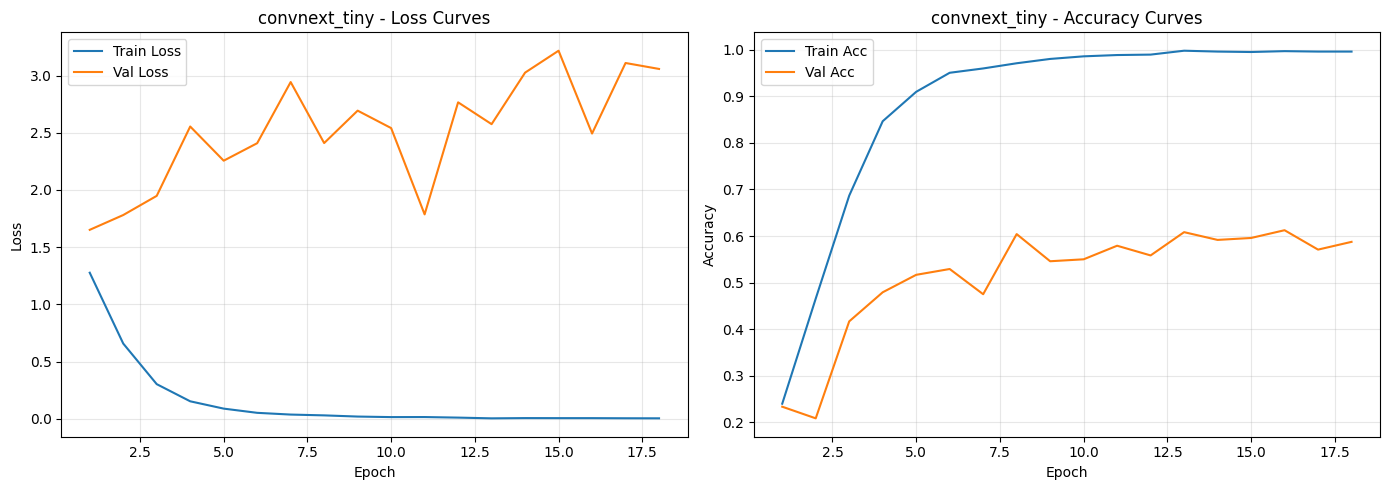

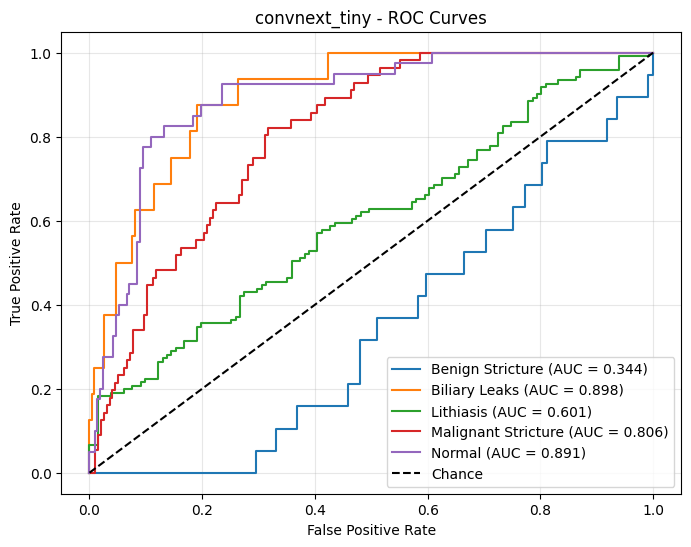


Starting benchmark for efficientnet_v2_s

=== efficientnet_v2_s architecture ===
EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): 

efficientnet_v2_s | Epoch 01 | Train Loss: 0.8669 | Train Acc: 0.3950 | Val Loss: 1.5274 | Val Acc: 0.2458 | Val Macro F1: 0.1617


efficientnet_v2_s | Epoch 02 | Train Loss: 0.3275 | Train Acc: 0.6729 | Val Loss: 1.8849 | Val Acc: 0.2542 | Val Macro F1: 0.2259


efficientnet_v2_s | Epoch 03 | Train Loss: 0.1829 | Train Acc: 0.7779 | Val Loss: 1.6252 | Val Acc: 0.4000 | Val Macro F1: 0.2945


efficientnet_v2_s | Epoch 04 | Train Loss: 0.1240 | Train Acc: 0.8708 | Val Loss: 1.4721 | Val Acc: 0.5583 | Val Macro F1: 0.4094


...

efficientnet_v2_s | Epoch 06 | Train Loss: 0.0712 | Train Acc: 0.9247 | Val Loss: 2.0653 | Val Acc: 0.5292 | Val Macro F1: 0.3469


efficientnet_v2_s | Epoch 07 | Train Loss: 0.0467 | Train Acc: 0.9498 | Val Loss: 2.1258 | Val Acc: 0.5375 | Val Macro F1: 0.3834


efficientnet_v2_s | Epoch 08 | Train Loss: 0.0607 | Train Acc: 0.9507 | Val Loss: 1.7567 | Val Acc: 0.4333 | Val Macro F1: 0.3166


efficientnet_v2_s | Epoch 09 | Train Loss: 0.0344 | Train Acc: 0.9693 | Val Loss: 1.8574 | Val Acc: 0.6208 | Val Macro F1: 0.4313


efficientnet_v2_s | Epoch 10 | Train Loss: 0.0164 | Train Acc: 0.9870 | Val Loss: 2.2945 | Val Acc: 0.5958 | Val Macro F1: 0.3928
Early stopping for efficientnet_v2_s at epoch 10


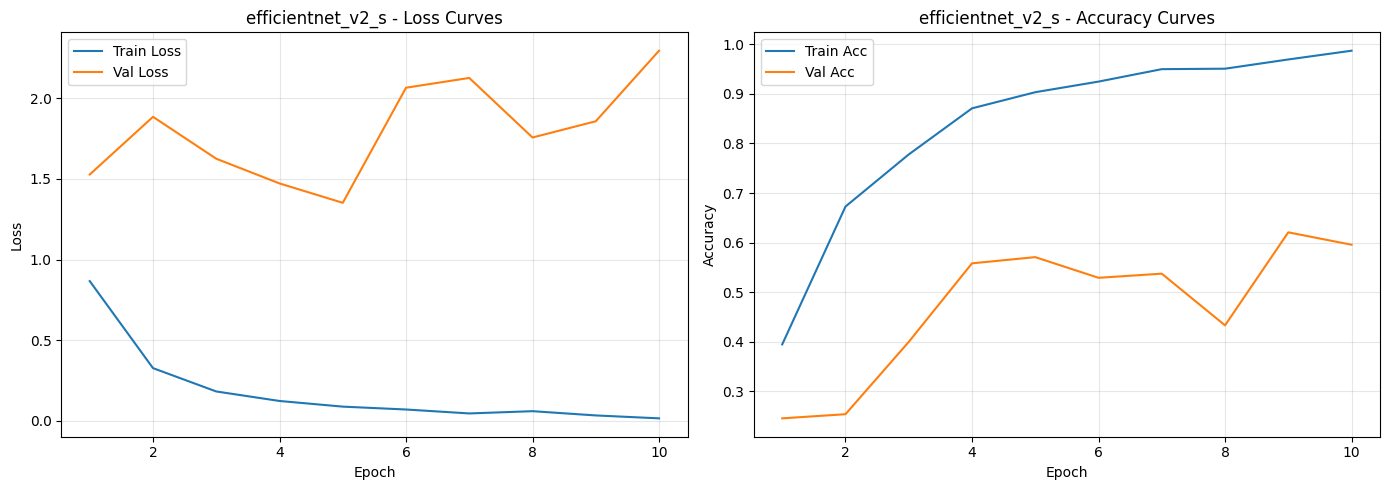

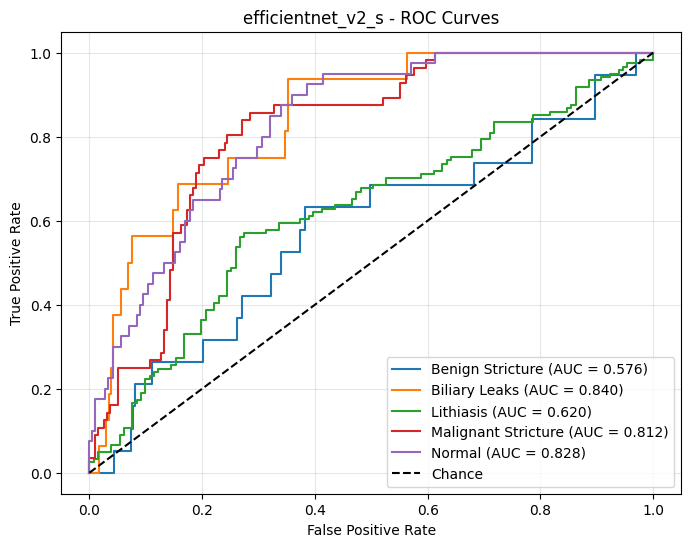


Starting benchmark for resnet50

=== resnet50 architecture ===
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequenti

resnet50 | Epoch 01 | Train Loss: 0.9852 | Train Acc: 0.3123 | Val Loss: 2.2154 | Val Acc: 0.2375 | Val Macro F1: 0.0781


resnet50 | Epoch 02 | Train Loss: 0.4148 | Train Acc: 0.5586 | Val Loss: 1.5014 | Val Acc: 0.3000 | Val Macro F1: 0.2367


resnet50 | Epoch 03 | Train Loss: 0.2751 | Train Acc: 0.6784 | Val Loss: 1.4502 | Val Acc: 0.2458 | Val Macro F1: 0.2205


resnet50 | Epoch 04 | Train Loss: 0.1999 | Train Acc: 0.7658 | Val Loss: 1.5660 | Val Acc: 0.3375 | Val Macro F1: 0.2574


...

resnet50 | Epoch 13 | Train Loss: 0.0183 | Train Acc: 0.9823 | Val Loss: 2.2890 | Val Acc: 0.5375 | Val Macro F1: 0.3642


resnet50 | Epoch 14 | Train Loss: 0.0100 | Train Acc: 0.9916 | Val Loss: 2.4436 | Val Acc: 0.5333 | Val Macro F1: 0.3371


resnet50 | Epoch 15 | Train Loss: 0.0111 | Train Acc: 0.9879 | Val Loss: 2.3967 | Val Acc: 0.5625 | Val Macro F1: 0.3757


resnet50 | Epoch 16 | Train Loss: 0.0120 | Train Acc: 0.9851 | Val Loss: 2.4367 | Val Acc: 0.5750 | Val Macro F1: 0.3736


resnet50 | Epoch 17 | Train Loss: 0.0095 | Train Acc: 0.9916 | Val Loss: 2.2329 | Val Acc: 0.5500 | Val Macro F1: 0.3619
Early stopping for resnet50 at epoch 17


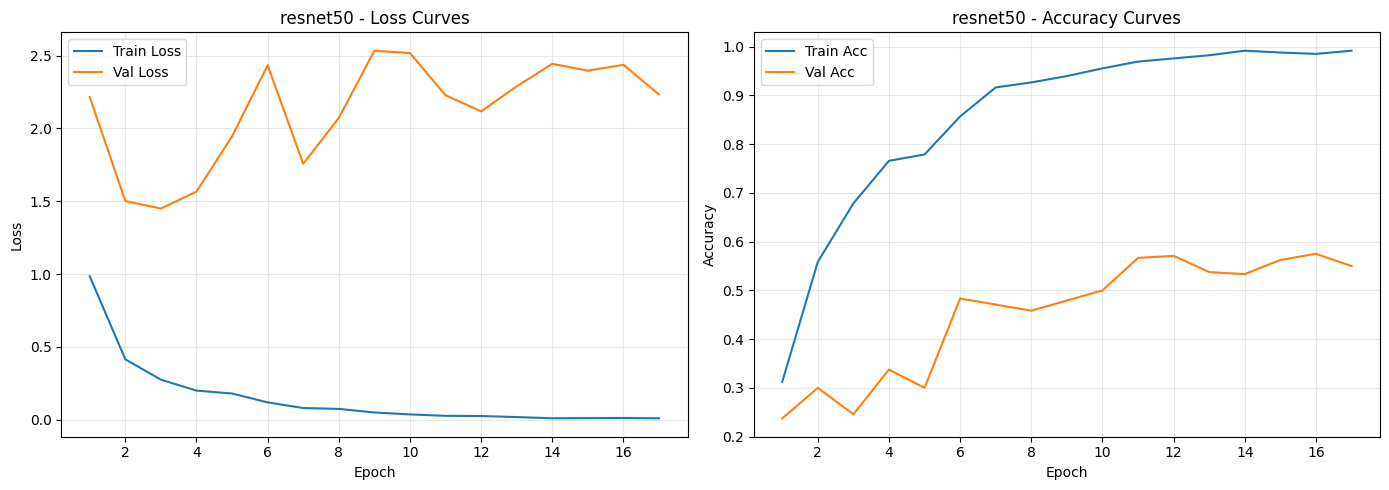

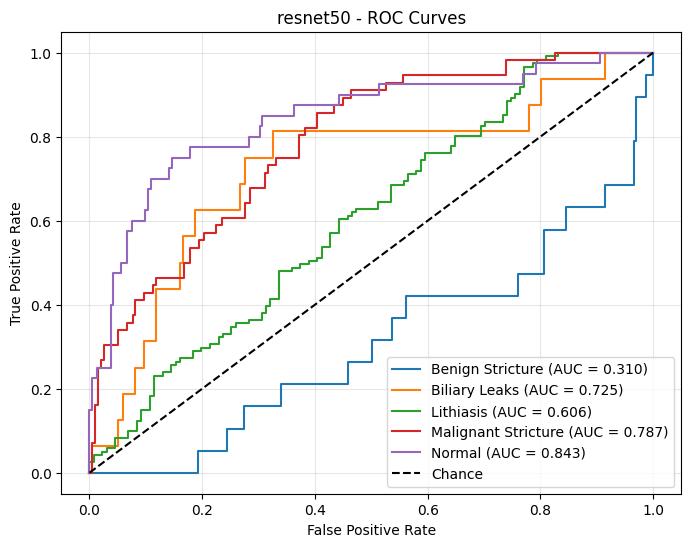


Starting benchmark for densenet121

=== densenet121 architecture ===
DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-

densenet121 | Epoch 01 | Train Loss: 0.7900 | Train Acc: 0.4043 | Val Loss: 1.9170 | Val Acc: 0.1833 | Val Macro F1: 0.1924


densenet121 | Epoch 02 | Train Loss: 0.2679 | Train Acc: 0.7128 | Val Loss: 1.6823 | Val Acc: 0.3125 | Val Macro F1: 0.2142


densenet121 | Epoch 03 | Train Loss: 0.1546 | Train Acc: 0.8336 | Val Loss: 1.5235 | Val Acc: 0.4042 | Val Macro F1: 0.3104


densenet121 | Epoch 04 | Train Loss: 0.1088 | Train Acc: 0.9024 | Val Loss: 1.4599 | Val Acc: 0.5625 | Val Macro F1: 0.4197


...

densenet121 | Epoch 10 | Train Loss: 0.0161 | Train Acc: 0.9898 | Val Loss: 1.7706 | Val Acc: 0.5542 | Val Macro F1: 0.3847


densenet121 | Epoch 11 | Train Loss: 0.0156 | Train Acc: 0.9879 | Val Loss: 2.0595 | Val Acc: 0.5083 | Val Macro F1: 0.3408


densenet121 | Epoch 12 | Train Loss: 0.0150 | Train Acc: 0.9870 | Val Loss: 2.2857 | Val Acc: 0.4958 | Val Macro F1: 0.2959


densenet121 | Epoch 13 | Train Loss: 0.0084 | Train Acc: 0.9944 | Val Loss: 2.0556 | Val Acc: 0.5250 | Val Macro F1: 0.3400


densenet121 | Epoch 14 | Train Loss: 0.0087 | Train Acc: 0.9991 | Val Loss: 1.9530 | Val Acc: 0.5500 | Val Macro F1: 0.3627
Early stopping for densenet121 at epoch 14


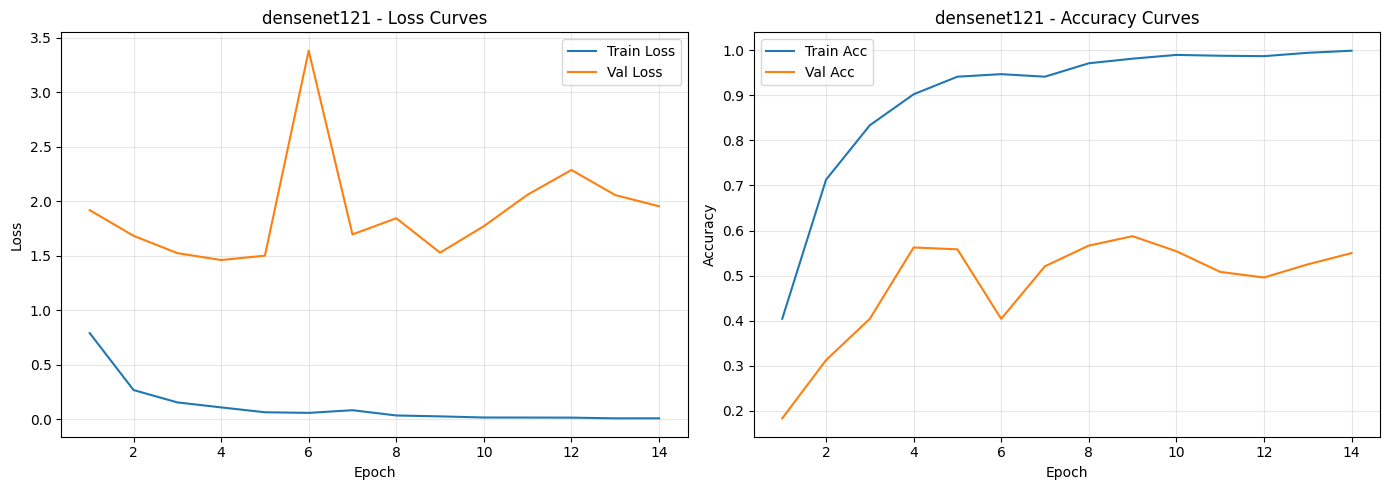

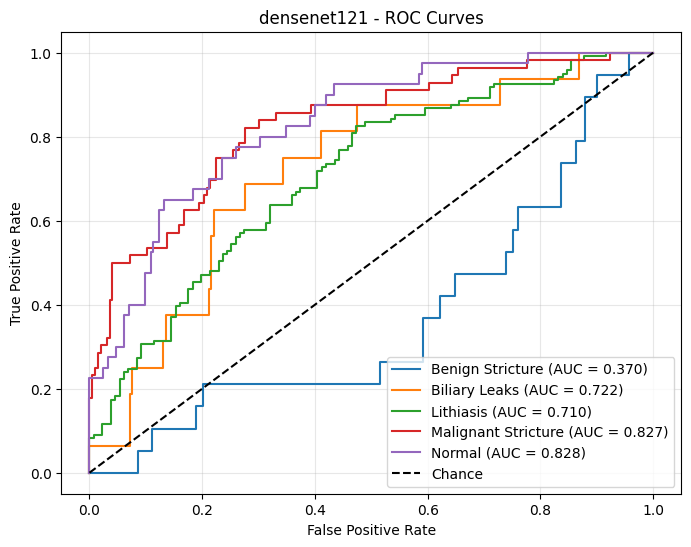


Benchmark summary:
          model_name  best_epoch  best_val_macro_f1  test_accuracy  \
2           resnet50          12           0.376047       0.543651   
0      convnext_tiny          13           0.441519       0.527778   
3        densenet121           9           0.420708       0.523810   
1  efficientnet_v2_s           5           0.456361       0.468254   

   test_balanced_accuracy  test_macro_f1  test_macro_precision  \
2                0.349965       0.337809              0.332920   
0                0.390570       0.368383              0.517791   
3                0.374100       0.348108              0.330169   
1                0.384023       0.322180              0.315412   

   test_macro_recall  test_roc_auc_ovo_macro  test_pr_auc_macro  test_loss  
2           0.349965                0.654174           0.387092   3.018942  
0           0.390570                0.708057           0.437215   3.410652  
3           0.374100                0.691594           0.429228   2

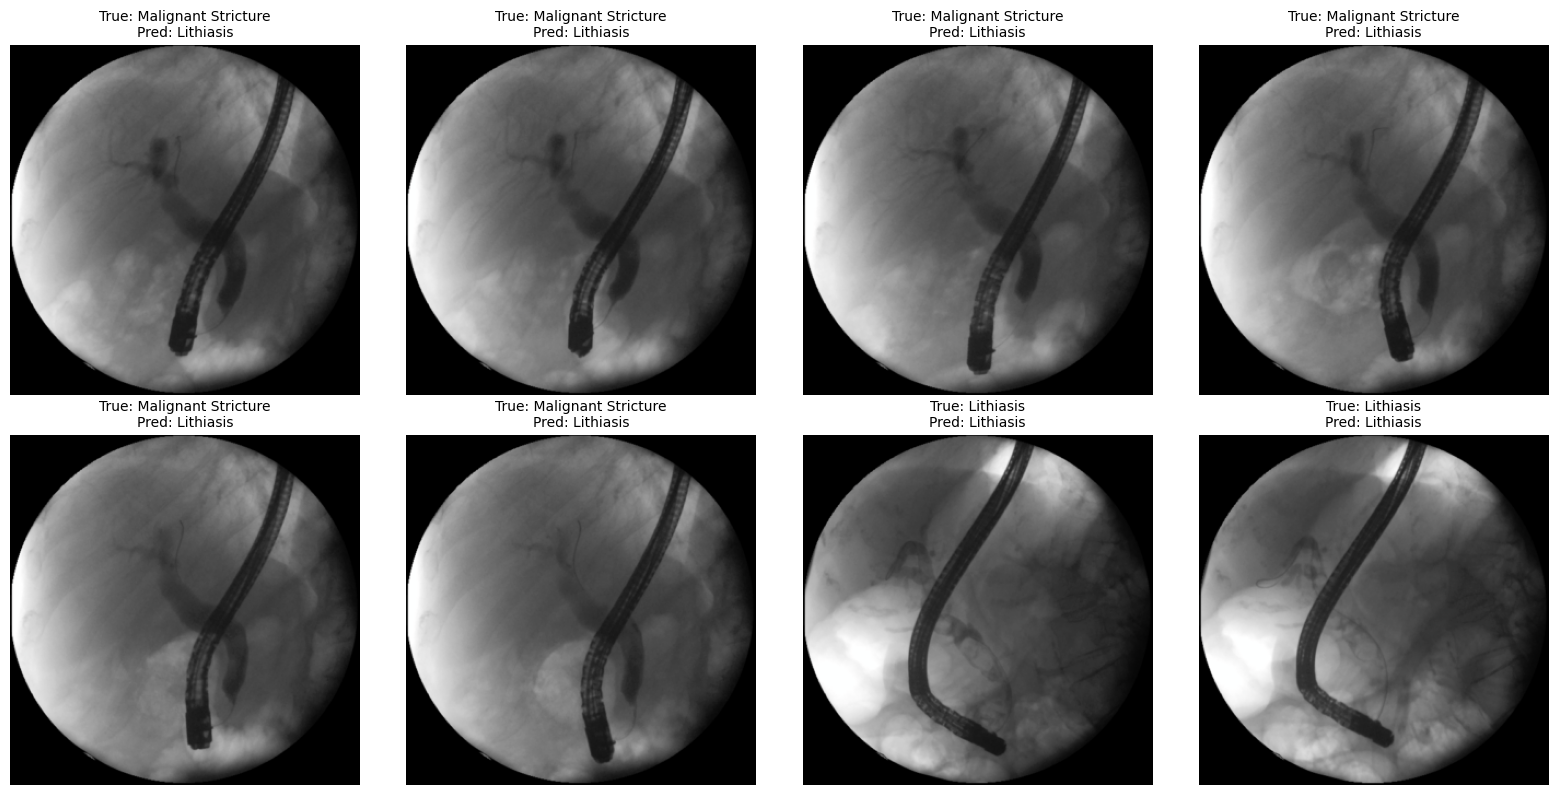

True labels: ['Malignant Stricture', 'Malignant Stricture', 'Malignant Stricture', 'Malignant Stricture', 'Malignant Stricture', 'Malignant Stricture', 'Lithiasis', 'Lithiasis']
Pred labels: ['Lithiasis', 'Lithiasis', 'Lithiasis', 'Lithiasis', 'Lithiasis', 'Lithiasis', 'Lithiasis', 'Lithiasis']


In [18]:
benchmark_results = []
trained_models = {}
for model_name in MODEL_NAMES:
    print(f'\nStarting benchmark for {model_name}')
    model, history, best_epoch, best_val_score = train_model(
        model_name,
        train_loader,
        val_loader,
        class_names,
        device,
        RESULTS_DIR,
        MODELS_DIR,
    )
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    test_metrics, y_true, y_pred, y_prob = evaluate_model(model, test_loader, criterion, class_names, device)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    confusion = confusion_matrix(y_true, y_pred)
    plot_curves(history, model_name, RESULTS_DIR)
    plot_roc_curve(y_true, y_prob, class_names, model_name, RESULTS_DIR)

    with open(os.path.join(RESULTS_DIR, f'{model_name}_classification_report.json'), 'w') as handle:
        json.dump(report, handle, indent=2)
    with open(os.path.join(RESULTS_DIR, f'{model_name}_history.json'), 'w') as handle:
        json.dump(history, handle, indent=2)
    pd.DataFrame(confusion, index=class_names, columns=class_names).to_csv(
        os.path.join(RESULTS_DIR, f'{model_name}_confusion_matrix.csv')
    )

    benchmark_results.append({
        'model_name': model_name,
        'best_epoch': best_epoch,
        'best_val_macro_f1': best_val_score,
        **{f'test_{key}': value for key, value in test_metrics.items()},
    })
    trained_models[model_name] = model

benchmark_results_df = pd.DataFrame(benchmark_results).sort_values(by='test_accuracy', ascending=False)
benchmark_results_df.to_csv(os.path.join(RESULTS_DIR, 'benchmark_summary.csv'), index=False)
print('\nBenchmark summary:')
print(benchmark_results_df)

best_model_name = benchmark_results_df.iloc[0]['model_name']
print(f'\nBest model according to test accuracy: {best_model_name}')
best_model = trained_models[best_model_name]

print('\nQuick inference sample from test loader:')
images, targets = next(iter(test_loader))
with torch.no_grad():
    logits = best_model(images.to(device))
    predictions = torch.argmax(torch.softmax(logits, dim=1), dim=1)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for axis, image_tensor, true_label, pred_label in zip(axes.flat, images[:8], targets[:8], predictions.cpu()[:8]):
    image = image_tensor.permute(1, 2, 0).cpu().numpy()
    image = np.clip((image * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406]), 0, 1)
    axis.imshow(image)
    axis.set_title(f'True: {idx_to_class[int(true_label)]}\nPred: {idx_to_class[int(pred_label)]}', fontsize=10)
    axis.axis('off')
plt.tight_layout()
plt.show()
print('True labels:', [idx_to_class[int(value)] for value in targets[:8]])
print('Pred labels:', [idx_to_class[int(value)] for value in predictions.cpu()[:8]])